lets try our model on different ICs

In [1]:
# ==============================================================
# Neural diffusion stepper – variable Δt, no physics input
# ==============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ---- Device setup (CPU / GPU) ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
CUDA version: 12.1
GPU: NVIDIA GeForce RTX 4090


In [2]:
# -----------------------
# 1. Diffusion solver
# -----------------------
def diffusion_solver(u0, nu=0.01, dx=1/128, dt=1e-4, n_steps=50000):
    """Explicit finite-difference diffusion solver (periodic BCs)."""
    u = u0.copy()
    traj = [u.copy()]
    for _ in range(n_steps):
        lap = (np.roll(u, -1) - 2*u + np.roll(u, 1)) / dx**2
        u = u + nu * dt * lap
        traj.append(u.copy())
    return np.stack(traj)


In [3]:

# -----------------------
# 2. Data (same as your GPU version)
# -----------------------
Nx = 256
dx = 1/Nx
dt0 = 1e-4
nu = 0.01
n_steps = 50000

x = np.linspace(0,1,Nx,endpoint=False)
# Move to GPU


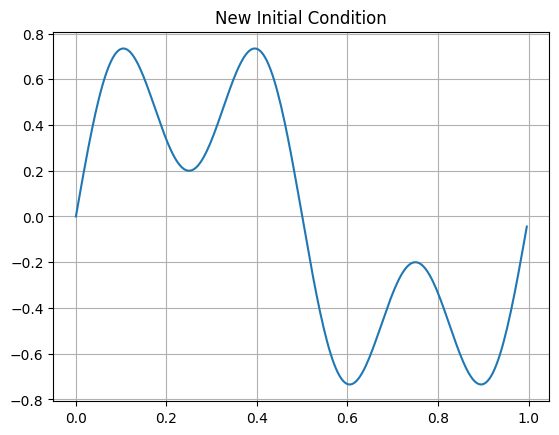

In [4]:
# %% [markdown]
# # Generate New Initial Condition (IC)

import numpy as np
import torch

def generate_IC(Nx, ic_type="sin", seed=0):
    x = np.linspace(0, 1, Nx, endpoint=False)

    if ic_type == "sin":
        return np.sin(2*np.pi*x)

    elif ic_type == "sin2":
        return np.sin(4*np.pi*x)

    elif ic_type == "mix":
        return 0.6*np.sin(2*np.pi*x) + 0.4*np.sin(6*np.pi*x)

    elif ic_type == "random":
        rng = np.random.default_rng(seed)
        u0 = rng.normal(0, 0.3, Nx)
        return u0

    elif ic_type == "square":
        u0 = np.zeros(Nx)
        u0[Nx//4 : 3*Nx//4] = 1.0
        return u0

    else:
        raise ValueError("Unknown IC type")

# Example:
u0_new = generate_IC(Nx, ic_type="mix")
plt.plot(x, u0_new)
plt.title("New Initial Condition")
plt.grid(True)
plt.show()


In [5]:
# -----------------------
# 3. Model 
# -----------------------
class MLPStepper(nn.Module):
    def __init__(self, in_dim=4, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1)
        )
    def forward(self, u_left, u_center, u_right, dt_norm):
        inp = torch.stack([u_left, u_center, u_right, dt_norm], dim=-1)
        du = self.net(inp).squeeze(-1)
        return u_center + 0.005*du

model = MLPStepper().to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = MLPStepper().to(device)

model.load_state_dict(torch.load("neural_diffusion_stepper.pt", map_location=device))
model.eval()

print("Model loaded successfully!")


Using device: cuda
Model loaded successfully!


C:\Users\amt35\AppData\Local\Temp\ipykernel_18960\3955568146.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("neural_diffusion_stepper.p

In [7]:
# simulate true diffusion for the new IC
data_new = diffusion_solver(u0_new, nu=0.01, dx=dx, dt=dt0, n_steps=25000)

# convert to torch
u_true_new = torch.tensor(data_new, dtype=torch.float32, device=device)


In [8]:
# %% [markdown]
# # Rollout NN on New IC

model.eval()
u_pred = torch.tensor(u0_new, dtype=torch.float32, device=device).unsqueeze(0)

rollout_pred_new = [u_pred[0].detach().cpu().numpy()]
rollout_true_new = [u_true_new[0].detach().cpu().numpy()]

steps = u_true_new.shape[0]

with torch.no_grad():
    for t in range(steps - 1):
        u_now = rollout_pred_new[-1]
        u_now = torch.from_numpy(u_now).to(device)

        u_left  = torch.roll(u_now, +1)
        u_right = torch.roll(u_now, -1)

        dt_vec = torch.ones_like(u_now)   # dt = 1

        u_next = model(u_left, u_now, u_right, dt_vec)

        rollout_pred_new.append(u_next.detach().cpu().numpy())
        rollout_true_new.append(u_true_new[t+1].detach().cpu().numpy())

rollout_pred_new = np.stack(rollout_pred_new)
rollout_true_new = np.stack(rollout_true_new)

print("Done! Rollout shape:", rollout_pred_new.shape)


Done! Rollout shape: (25001, 256)


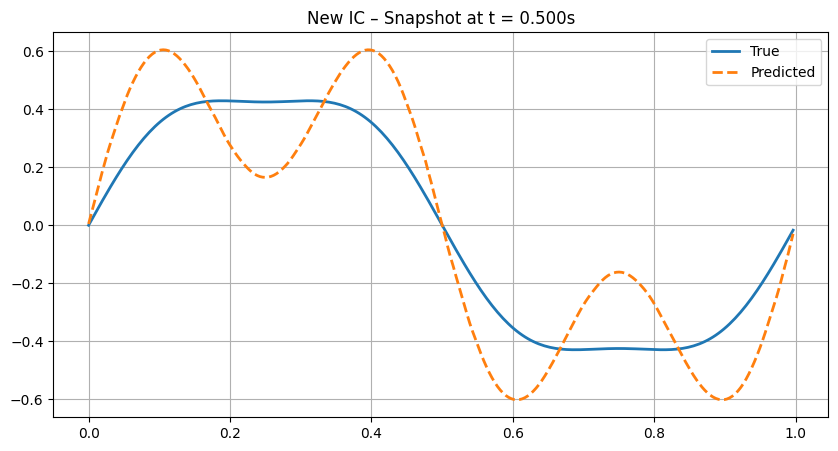

In [9]:
snapshot = 5000   # choose any step

plt.figure(figsize=(10,5))
plt.plot(x, rollout_true_new[snapshot], label="True", linewidth=2)
plt.plot(x, rollout_pred_new[snapshot], label="Predicted", linestyle="--", linewidth=2)
plt.title(f"New IC – Snapshot at t = {snapshot * dt0:.3f}s")
plt.grid(True)
plt.legend()
plt.show()


Using device: cuda
✓ Loaded neural_diffusion_stepper.pt


C:\Users\amt35\AppData\Local\Temp\ipykernel_18960\2010942020.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("neural_diffusion_stepper

Shapes: (8001, 256) (8000, 256)


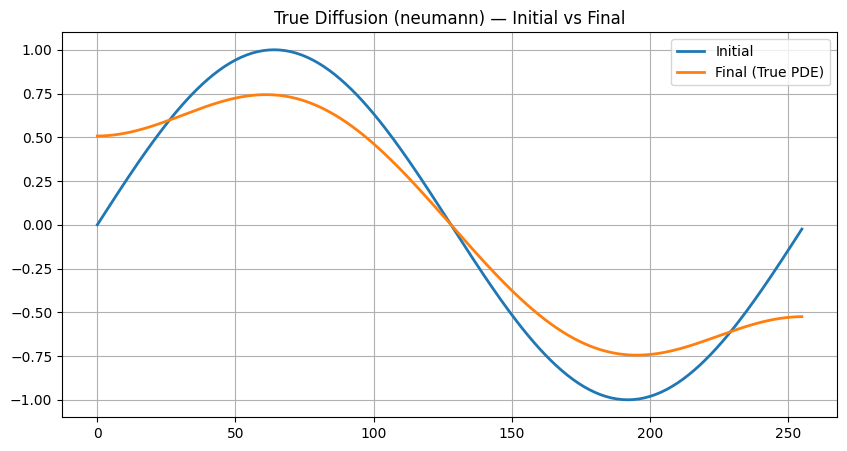

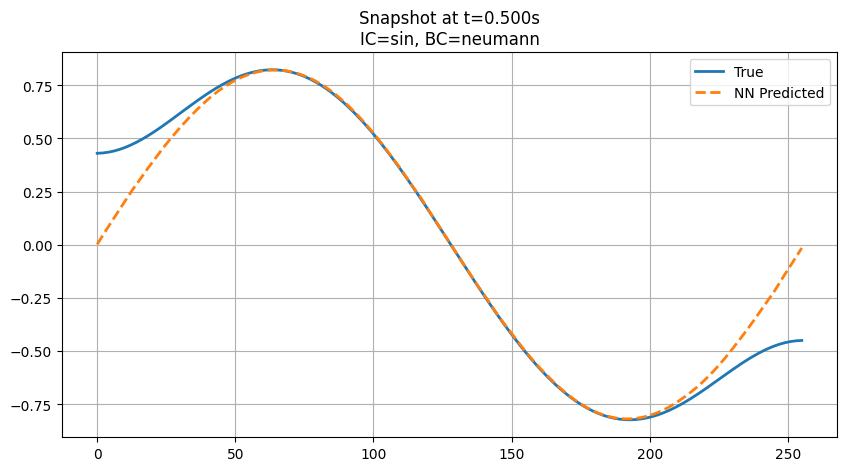

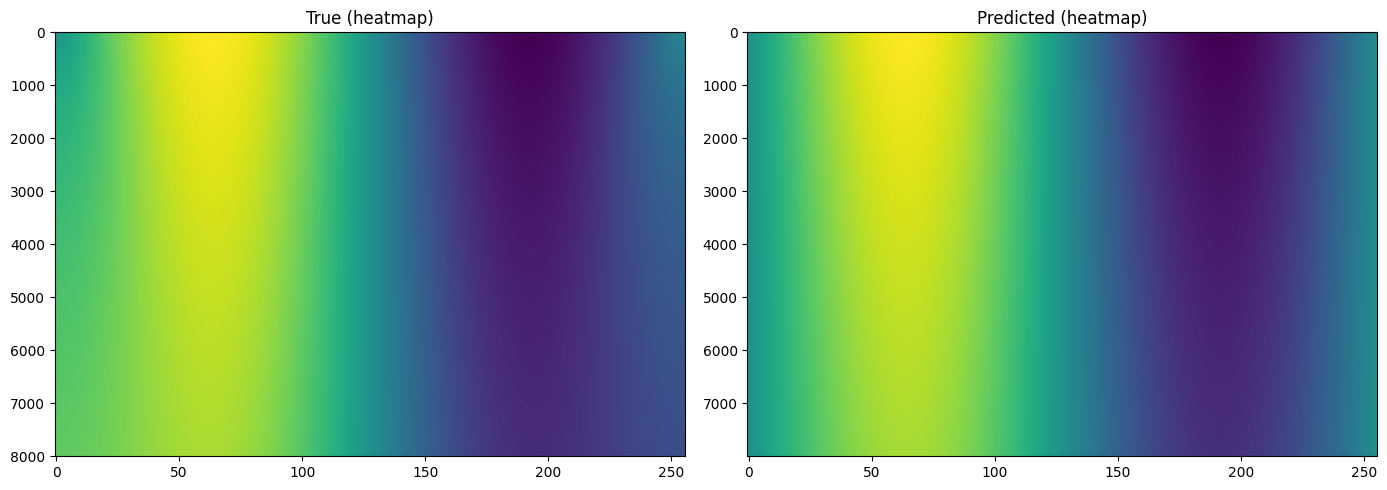

In [10]:
# %%
# =============================================================
# Test Neural Diffusion Stepper under Different ICs + BCs
# =============================================================

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# =============================================================
# 1. Define IC Generators
# =============================================================

def generate_IC(Nx, ic_type="sin", seed=0):
    x = np.linspace(0, 1, Nx, endpoint=False)

    if ic_type == "sin":
        return np.sin(2*np.pi*x)

    elif ic_type == "sin2":
        return np.sin(4*np.pi*x)

    elif ic_type == "mix":
        return 0.6*np.sin(2*np.pi*x) + 0.4*np.sin(6*np.pi*x)

    elif ic_type == "random":
        rng = np.random.default_rng(seed)
        return rng.normal(0, 0.3, Nx)

    elif ic_type == "square":
        u = np.zeros(Nx)
        u[Nx//4:3*Nx//4] = 1.0
        return u

    else:
        raise ValueError("Unknown IC type")


# =============================================================
# 2. Boundary Condition Laplacians
# =============================================================

def laplacian_periodic(u, dx):
    return (np.roll(u, -1) - 2*u + np.roll(u, 1)) / dx**2


def laplacian_dirichlet(u, dx):
    lap = np.zeros_like(u)
    lap[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
    lap[0] = 0
    lap[-1] = 0
    return lap


def laplacian_neumann(u, dx):
    lap = np.zeros_like(u)
    lap[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
    lap[0] = (u[1] - u[0]) / dx**2
    lap[-1] = (u[-2] - u[-1]) / dx**2
    return lap


# =============================================================
# 3. PDE Solver with selectable BC
# =============================================================

def diffusion_solver(u0, nu, dx, dt, n_steps, bc="periodic"):
    u = u0.copy()
    traj = [u.copy()]

    for _ in range(n_steps):

        if bc == "periodic":
            lap = laplacian_periodic(u, dx)
        elif bc == "dirichlet":
            lap = laplacian_dirichlet(u, dx)
        elif bc == "neumann":
            lap = laplacian_neumann(u, dx)
        else:
            raise ValueError("Unknown BC type")

        u = u + nu * dt * lap
        traj.append(u.copy())

    return np.stack(traj)


# =============================================================
# 4. Neural Network Model (same as training)
# =============================================================

class MLPStepper(nn.Module):
    def __init__(self, in_dim=4, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1)
        )

    def forward(self, u_left, u_center, u_right, dt_norm):
        inp = torch.stack([u_left, u_center, u_right, dt_norm], dim=-1)
        du = self.net(inp).squeeze(-1)
        return u_center + 0.005 * du


# =============================================================
# 5. Load trained NN
# =============================================================

model = MLPStepper().to(device)
model.load_state_dict(torch.load("neural_diffusion_stepper.pt", map_location=device))
model.eval()

print("✓ Loaded neural_diffusion_stepper.pt")


# =============================================================
# 6. NN Rollout with selectable BC
# =============================================================

def nn_rollout(u0, dt, steps, bc="periodic"):
    u_pred = torch.tensor(u0, dtype=torch.float32, device=device)
    traj = [u_pred.detach().cpu().numpy()]

    for _ in range(steps - 1):

        # Apply BC logic for neighbors
        if bc == "periodic":
            u_left = torch.roll(u_pred, +1)
            u_right = torch.roll(u_pred, -1)

        elif bc == "dirichlet":
            u_left = torch.zeros_like(u_pred)
            u_right = torch.zeros_like(u_pred)
            u_left[1:] = u_pred[:-1]
            u_right[:-1] = u_pred[1:]

        elif bc == "neumann":
            u_left = torch.zeros_like(u_pred)
            u_right = torch.zeros_like(u_pred)
            u_left[1:] = u_pred[:-1]
            u_right[:-1] = u_pred[1:]
            u_left[0] = u_pred[0]
            u_right[-1] = u_pred[-1]

        else:
            raise ValueError("Unknown BC type")

        dt_vec = torch.ones_like(u_pred) * dt

        with torch.no_grad():
            u_pred = model(u_left, u_pred, u_right, dt_vec)

        traj.append(u_pred.detach().cpu().numpy())

    return np.stack(traj)


# =============================================================
# 7. Run an experiment
# =============================================================

Nx = 256
dx = 1/Nx
dt0 = 1e-4
nu = 0.01
n_steps = 8000   # rollout length

# Choose IC and BC
IC_type = "sin"          # sin, sin2, mix, random, square
BC_type = "neumann"    # periodic, dirichlet, neumann

# Generate IC
u0 = generate_IC(Nx, IC_type)

# Compute TRUE diffusion
true_traj = diffusion_solver(u0, nu, dx, dt0, n_steps, bc=BC_type)

# NN prediction
pred_traj = nn_rollout(u0, dt=1, steps=n_steps, bc=BC_type)

print("Shapes:", true_traj.shape, pred_traj.shape)


# =============================================================
# 8. Plot Initial vs Final (True PDE)
# =============================================================

plt.figure(figsize=(10,5))
plt.plot(true_traj[0], label="Initial", linewidth=2)
plt.plot(true_traj[-1], label="Final (True PDE)", linewidth=2)
plt.title(f"True Diffusion ({BC_type}) — Initial vs Final")
plt.grid(True)
plt.legend()
plt.show()


# =============================================================
# 9. Plot True vs NN (Snapshot)
# =============================================================

snapshot = 5000

plt.figure(figsize=(10,5))
plt.plot(true_traj[snapshot], label="True", linewidth=2)
plt.plot(pred_traj[snapshot], label="NN Predicted", linestyle="--", linewidth=2)
plt.title(f"Snapshot at t={snapshot * dt0:.3f}s\nIC={IC_type}, BC={BC_type}")
plt.grid(True)
plt.legend()
plt.show()


# =============================================================
# 10. Heatmap Comparison
# =============================================================

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.title("True (heatmap)")
plt.imshow(true_traj, aspect="auto", cmap="viridis")
plt.subplot(1,2,2)
plt.title("Predicted (heatmap)")
plt.imshow(pred_traj, aspect="auto", cmap="viridis")
plt.tight_layout()
plt.show()
